In [3]:
import json
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from nltk.tokenize import word_tokenize
from scipy.optimize import curve_fit

sys.path.append('../../..')
from style_setup import set_thesis_style

set_thesis_style()

In [7]:
def remove_markdown(sentence):
    """
    Remove markdown formatting from a sentence.
    """
    sentence = re.sub(r'#+', '', sentence)  # Remove all # symbols
    sentence = re.sub(r'\*\*', '', sentence)  # Remove **
    sentence = re.sub(r'\*', '', sentence)  # Remove *
    return sentence

def heaps_law(n, K, beta):
    """Heaps' Law model function."""
    return K * (n ** beta)

def extract_text_from_jsonl(file_path, response_key):
    """
    Extracts and concatenates text from a JSONL file.

    Args:
        file_path (str): The path to the JSONL file.
        response_key (str): The key in the JSON objects that contains the text.

    Returns:
        str: A single string containing all the extracted text.
    """
    all_data = ""
    with open(file_path, "r", encoding='utf-8') as f:
        for line in f:
            try:
                data = json.loads(line)
                if response_key in data:
                    all_data += data[response_key]
            except json.JSONDecodeError:
                print(f"Warning: Could not decode JSON from a line in {file_path}")
    return all_data

def calculate_heaps_parameters(text, sample_step=1000):
    """
    Calculates Heaps' law parameters (K and beta) for a given text.

    Args:
        text (str): The input text.
        sample_step (int): The step size for sampling token counts.

    Returns:
        tuple: A tuple containing (K, beta, N_values, V_values).
    """
    text = remove_markdown(text)
    tokens = word_tokenize(text.lower())

    vocab = set()
    N_values = []
    V_values = []

    for i in range(sample_step, len(tokens) + 1, sample_step):
        current_tokens = tokens[:i]
        vocab.update(current_tokens)
        N_values.append(i)
        V_values.append(len(vocab))

    if not N_values or not V_values:
        return None, None, [], []

    try:
        params, _ = curve_fit(heaps_law, N_values, V_values)
        k, beta = params
        return k, beta, N_values, V_values
    except RuntimeError:
        print("Warning: Could not fit the curve for Heaps' law. Not enough data points?")
        return None, None, N_values, V_values

def process_files_for_heaps(files_to_process):
    """
    Processes a list of files to calculate Heaps' law parameters for each.

    Args:
        files_to_process (list): A list of tuples, where each tuple is
                                 (file_path, response_key, display_name).

    Returns:
        pd.DataFrame: A DataFrame containing the Heaps' law parameters for each file.
    """
    results = []
    for file_path, response_key, name in files_to_process:
        print(f"Processing {name}...")
        text = extract_text_from_jsonl(file_path, response_key)
        if not text:
            print(f"Warning: No text extracted from {file_path}. Skipping.")
            continue
            
        k, beta, N, V = calculate_heaps_parameters(text)
        if k is not None:
            results.append({
                'name': name,
                'k': k,
                'beta': beta,
                'N': N,
                'V': V
            })
    return pd.DataFrame(results)

def plot_heaps_curves(df, title="Heaps' Law: Vocabulary Growth", plot_actual_data=False, save_path=None):
    """
    Plots the Heaps' Law curves from a DataFrame of parameters.

    Args:
        df (pd.DataFrame): DataFrame with 'name', 'k', 'beta', 'N', 'V' columns.
        title (str): The title of the plot.
        plot_actual_data (bool): Whether to plot the observed data points.
        save_path (str, optional): Path to save the plot. If None, plot is not saved.
    """
    plt.figure(figsize=(12, 8))
    
    # Use the default color cycle from matplotlib, which should be set by set_thesis_style()
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    max_n = df['N'].apply(lambda x: max(x) if x else 0).max()
    
    for i, row in df.iterrows():
        color = colors[i % len(colors)]
        
        if plot_actual_data and row['N']:
            plt.scatter(row['N'], row['V'], alpha=0.3, color=color)

        if row['k'] and row['beta'] and row['N']:
            x_range = np.linspace(min(row['N']), max_n, 100)
            plt.plot(x_range, heaps_law(x_range, row['k'], row['beta']),
                     label=f"{row['name']} (k={row['k']:.2f}, β={row['beta']:.2f})",
                     color=color)

    plt.xlabel('Number of Tokens (N)', fontsize=14)
    plt.ylabel('Vocabulary Size (V)', fontsize=14)
    plt.title(title, fontsize=16)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(loc='best', fontsize=12)
    plt.grid(True, which="both", ls="--", alpha=0.3)
    plt.tight_layout()
    
    # Save the plot if save_path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to: {save_path}")
    
    plt.show()

### Small models

In [ ]:
files_to_process = [
    (
        '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/small/outputs/output_lora_llama_8b_single.jsonl',
        'response_model', 
        'Llama 8B Single-Source'
    ),
    (
        '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/small/outputs/output_lora_llama_8b_multi.jsonl',
        'response_model',  
        'Llama 8B Multi-Source'
    ),
    (
        '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/small/outputs/output_lora_llama_8b_human.jsonl',
        'response_model',  
        'Llama 8B Human-Source'
    ),
    (
        '/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Small/Llama/dolly_test_Llama.jsonl',
        'response_model', 
        'Llama 8B Vanilla'
    )
]

# Calculate Heaps' law parameters
heaps_parameters_df = process_files_for_heaps(files_to_process)

# Display the results
print("\nCalculated Heaps' Law Parameters:")
display(heaps_parameters_df[['name', 'k', 'beta']])

# Plot the curves
if not heaps_parameters_df.empty:
    plot_heaps_curves(heaps_parameters_df, title="Heaps' Law for Llama 8B models", plot_actual_data=False, save_path='/Users/maxschaffelder/Desktop/Thesis/plots/exp_1/lex_div/heaps/heaps_law_llama_8b.png')


Processing Llama 8B Single-Source...
Processing Llama 8B Multi-Source...
Processing Llama 8B Human-Source...
Processing Llama 8B Vanilla...

Calculated Heaps' Law Parameters:


,name,k,beta
0,Llama 8B Single-Source,11.001317,0.602753
1,Llama 8B Multi-Source,11.777839,0.598482
2,Llama 8B Human-Source,5.291176,0.670528
3,Llama 8B Vanilla,10.241052,0.610814


### Medium models

Processing Llama 70B Single-Source...
Processing Llama 70B Multi-Source...
Processing Llama 70B Human-Source...
Processing Llama 70B Vanilla...

Calculated Heaps' Law Parameters:


,name,k,beta
0,Llama 70B Single-Source,10.723141,0.608035
1,Llama 70B Multi-Source,11.019247,0.606206
2,Llama 70B Human-Source,5.928573,0.671711
3,Llama 70B Vanilla,11.248004,0.604920


Plot saved to: /Users/maxschaffelder/Desktop/Thesis/plots/exp_1/lex_div/heaps/heaps_law_llama_70b.png


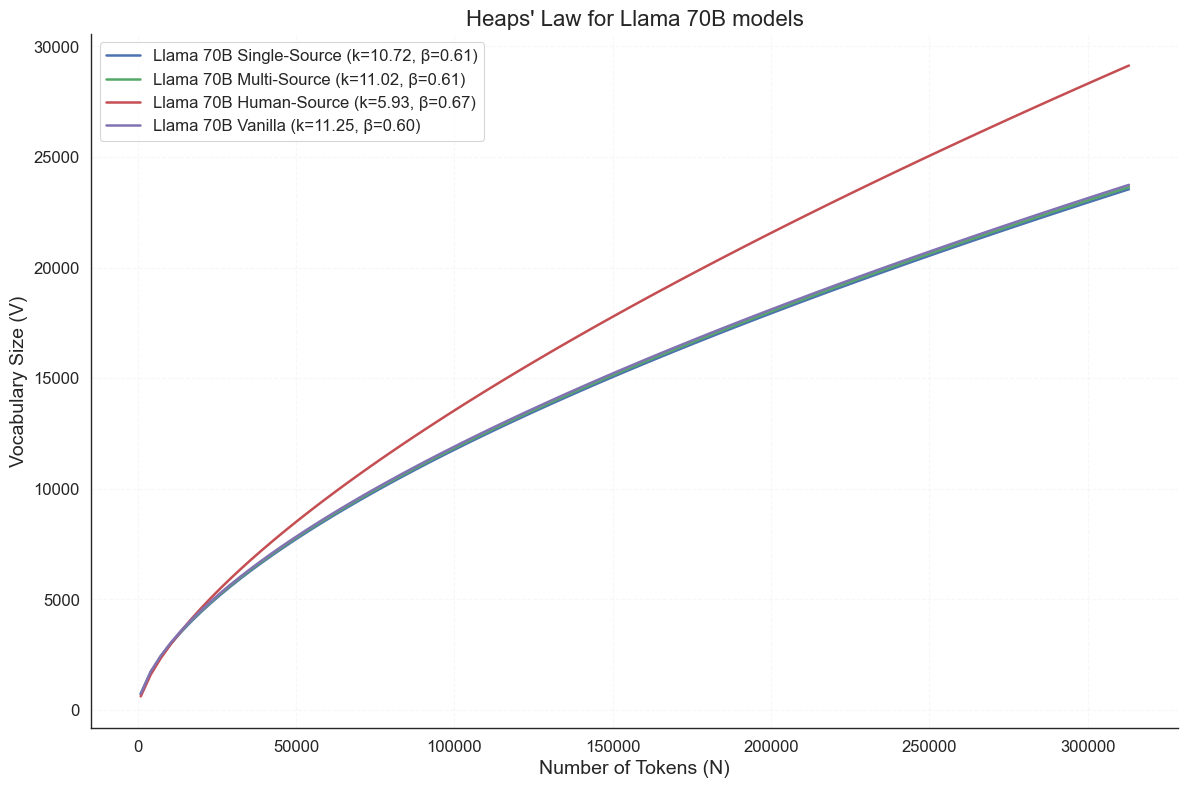

In [10]:
files_to_process = [
    (
        '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/outputs/output_llama_70b_single_source_medium.jsonl',
        'response_model', 
        'Llama 70B Single-Source'
    ),
    (
        '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/outputs/output_llama_70b_multi_source_medium.jsonl',
        'response_model',  
        'Llama 70B Multi-Source'
    ),
    (
        '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/outputs/output_llama_70b_human_source.jsonl',
        'response_model',  
        'Llama 70B Human-Source'
    ),
    (
        '/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Medium/Llama/dolly_test_Llama.jsonl',
        'response_model', 
        'Llama 70B Vanilla'
    )
]

# Calculate Heaps' law parameters
heaps_parameters_df = process_files_for_heaps(files_to_process)

# Display the results
print("\nCalculated Heaps' Law Parameters:")
display(heaps_parameters_df[['name', 'k', 'beta']])

# Plot the curves
if not heaps_parameters_df.empty:
    plot_heaps_curves(heaps_parameters_df, title="Heaps' Law for Llama 70B models", plot_actual_data=False, save_path='/Users/maxschaffelder/Desktop/Thesis/plots/exp_1/lex_div/heaps/heaps_law_llama_70b.png')


### Medium with large data

Processing Llama 70B Single-Source...
Processing Llama 70B Multi-Source...
Processing Llama 70B Human-Source...
Processing Llama 70B Vanilla...

Calculated Heaps' Law Parameters:


,name,k,beta
0,Llama 70B Single-Source,9.907445,0.613357
1,Llama 70B Multi-Source,10.240255,0.610087
2,Llama 70B Human-Source,5.928573,0.671711
3,Llama 70B Vanilla,11.248004,0.604920


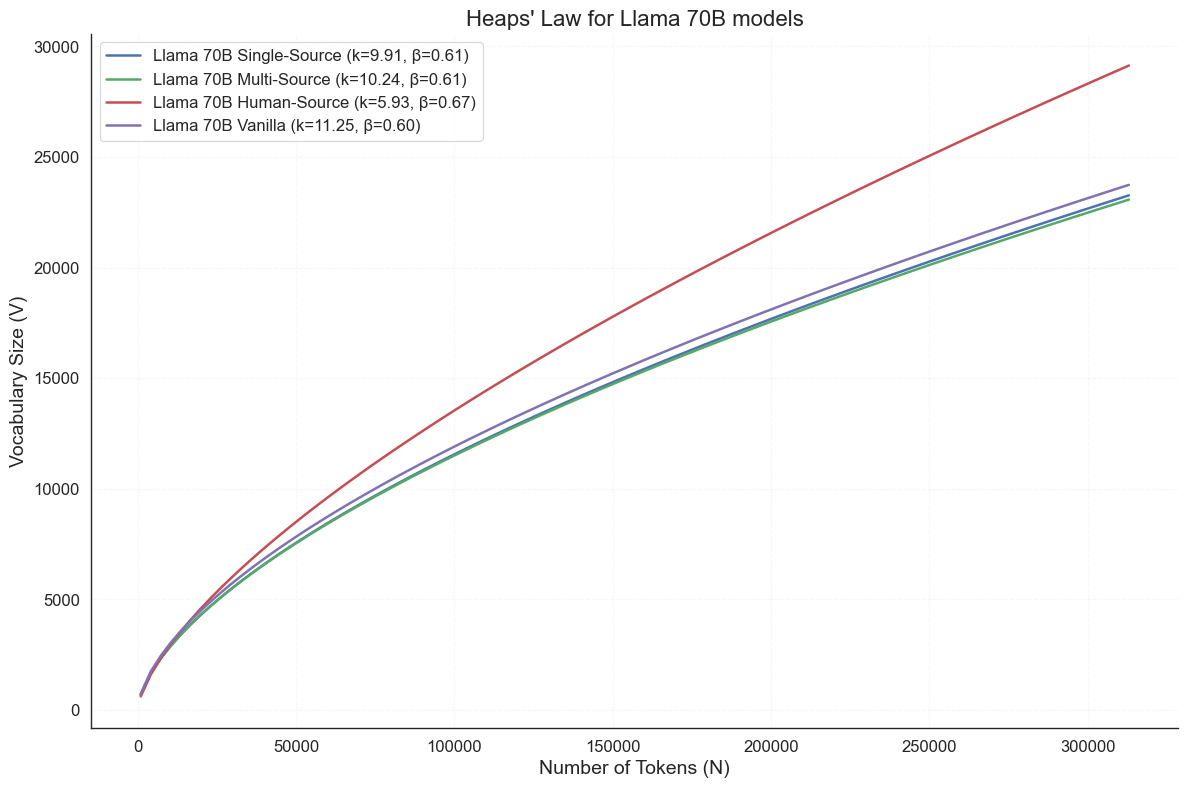

In [12]:
files_to_process = [
    (
        '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/outputs/output_llama_70b_single_source_small.jsonl',
        'response_model', 
        'Llama 70B Single-Source'
    ),
    (
        '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/outputs/output_llama_70b_multi_source_small.jsonl',
        'response_model',  
        'Llama 70B Multi-Source'
    ),
    (
        '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/outputs/output_llama_70b_human_source.jsonl',
        'response_model',  
        'Llama 70B Human-Source'
    ),
    (
        '/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Medium/Llama/dolly_test_Llama.jsonl',
        'response_model', 
        'Llama 70B Vanilla'
    )
]

# Calculate Heaps' law parameters
heaps_parameters_df = process_files_for_heaps(files_to_process)

# Display the results
print("\nCalculated Heaps' Law Parameters:")
display(heaps_parameters_df[['name', 'k', 'beta']])

# Plot the curves
if not heaps_parameters_df.empty:
    plot_heaps_curves(heaps_parameters_df, title="Heaps' Law for Llama 70B models", plot_actual_data=False)#, save_path='/Users/maxschaffelder/Desktop/Thesis/plots/exp_1/lex_div/heaps/heaps_law_llama_70b.png')
